# TO DO:
- mettere flag per se liner e se difetto quando li trovo
- mettere check flag se liner per task 2 
- mettere check flag se difetto per fare il rettangolo
- controllare visibilità variabili
- fare print finale fatto bene
- fare tutti i markdown in bella
- aggiungere "bibliografia" in fondo con link documentation
- magari salviamo l'immagine finale con tutta la roba per tutte le immagini così lo riesce a vedere al volo che viene per tutte senza dover modificare il nome e runnare dodici volte il codice




# esame data
# progetto
# nomi 

# breve descrizione progetto
setup generale

task da svolgere (scrivi numerazione usata qua quindi task 1.1,1.2,1.3 task 2)

In [110]:
# import tutto 
import numpy as np
import cv2
from matplotlib import pyplot as plt
import math

Setup 

In [111]:
#setup iniziale
#load image in modo carino per scegliere quale immagine loadare
img_name = "d_19"
show_steps = True

loadiamo immagine in color per poi farla visualizzare con i cerchi colorati però poi ci serve in gray scale per fare tutta la roba quindi ci creiamo anche la versione grayscale

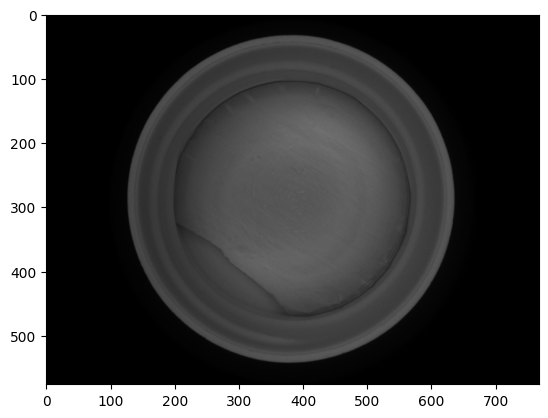

In [112]:
img_color = cv2.imread("cap-inspection-images/project_1_liner_inspection/"+img_name+".bmp")
img = cv2.cvtColor(img_color,cv2.COLOR_BGR2GRAY)
if show_steps :
    plt.figure()
    plt.imshow(img,cmap='gray',vmin=0,vmax=255)
    plt.show()

###  spiegazione tool usati: 
- gaussian filtering (cos'è, parametri, come scegliamo i parametri in questo caso, perchè questo piuttosto che altri)
- CLAHE - cos'è e perchè lo vogliamo usare, parametri 
- circlesHough (cos'è, come funziona a grandi linee, perchè lo usiamo, parametri)
- canny 
- HoughLines (cos'è, come funziona a grandi linee, perchè lo usiamo, parametri)


2 opzioni: li mettiamo tutti qua inordine di uso e scrivendo dove vengono usati dopo tipo reference OPPURE li mettiamo di volta in volta quando li usiamo nei vari step

caso uno magari qua facciamo una spiegazione generale e poi step per step l'uso specifico e soprattutto la scelta dei parametri


## ENHANCING THE IMAGE 

CLAHE + GAUSSIAN

spiegare perchè gaussian

In [113]:

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(5,5))
img_cl = clahe.apply(img)
img_blur = cv2.GaussianBlur(img_cl,(7,7),1.5)

## maybe mostriamo il confronto tra immagine originale e immagine enhanced dentro if show_steps

## TASK 1
### trovare il cerchio esterno
usiamo houghcircles mettendo parametri 40,100,80 perche pochi centri, canny con threshold alta mi prende solo il bordo esterno con grandiente alto, vogliamo cerchi belli

CAP OUTLINE - center: x =  382.5  y =  286.5  , diameter =  505.8


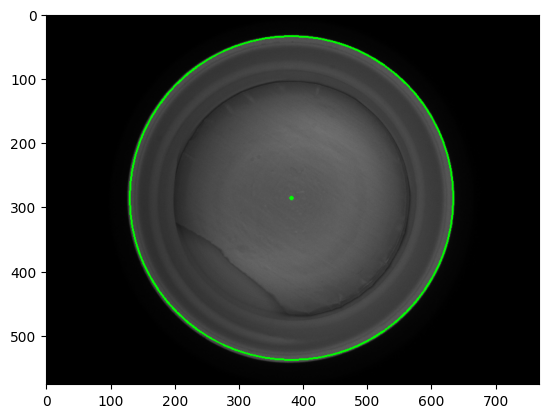

In [114]:
circles_out = cv2.HoughCircles(img_blur,cv2.HOUGH_GRADIENT, 1, 40,param1=100,param2=80) # ok per trovare esterno dei tappi
center_out = (circles_out[0][0][0],circles_out[0][0][1])
radius_out = circles_out[0][0][2]
cv2.circle(img_color,(int(center_out[0]),int(center_out[1])),int(radius_out),color=(0, 255, 0),thickness=2)
cv2.circle(img_color,(int(center_out[0]),int(center_out[1])),int(2),color=(0, 255, 0),thickness=2)
if show_steps:  
    #### maybe questo mostriamolo a prescindere
    print("CAP OUTLINE - center: x = ", center_out[0]," y = ",center_out[1]," , diameter = ",radius_out*2 )
    plt.imshow(img_color)
    plt.show()


## liner inspection
 
### facciamo la roi 
- perche (perche ci interessa solo l'interno del cap e a fare così riusciamo a vedere solo le info utili con canny e compagnia bella)

dimensione della roi scelto empiricamente tra inscritto (veniva tagliato il liner) e circoscritto (rimaneva troppo il bordo esterno) in questo modo tagli il giusto

### troviamo se il liner c'è o no
nostra soluzione: usiamo houghcircles con un param aggiustati per avere il canny interno che mostra più cose 

funziona a trovare se c'è il liner perche nel caso no liner canny con questi parametri non mostra niente dentro il cap

metodo alternativo: seguendo hint della consegna si può fare con avg lightness ** o mettiamo qua le due righine o appendice **

avg=cv2.mean(img_roi)[0]
print(avg)              ########## LINER: intorno a 97 - NO LINER: intorno a 107 - "threshold"=102 
if avg>102 : 
    print("NO LINER")
else : 
    # cerca i difetti


### se il liner c'è trova se c'è difetti 
facciamo manualmente canny (che inspecta il magnitude of the gradient) e poi houghlines (perche lui in automatico non lo fa a differenza di houghcircles)

se trova linee vuol dire che c'è il difetto altrimenti no difetto

LINER FOUND


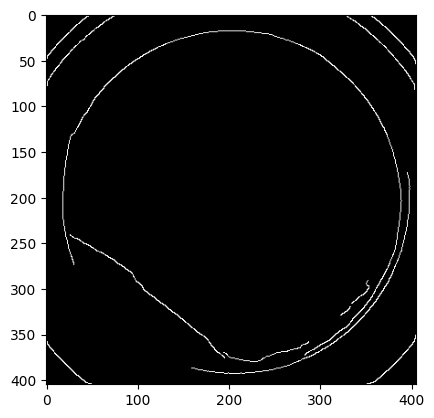

LINER DEFECT DETECTED


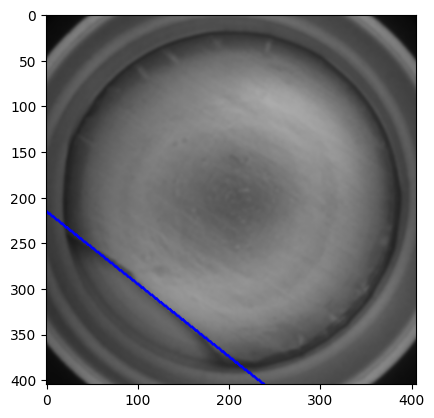

In [115]:
#### ROI OF INSIDE THE CAP
offset = radius_out*0.8 
x_max_roi=math.ceil(center_out[0]+offset)
x_min_roi=math.floor(center_out[0]-offset)
y_max_roi=math.ceil(center_out[1]+offset)
y_min_roi=math.floor(center_out[1]-offset)  

img_roi=img_blur[y_min_roi:y_max_roi,x_min_roi:x_max_roi]
img_roi_show=cv2.cvtColor(img_roi, cv2.COLOR_GRAY2RGB) ##### utile per mostrare step intermedi


circles_in = cv2.HoughCircles(img_roi,cv2.HOUGH_GRADIENT, 1, 50,param1=90,param2=80) # d_18 ne trova 3 ma il primo è quello giusto

line_layer=np.zeros_like(img_color) ############################################################################################################# PROVA PER RIQUADRO

if circles_in is not None and len(circles_in) > 0:  ###settare flag liner si 
    
    print("LINER FOUND")
    edges = cv2.Canny(img_roi,40,83,apertureSize = 3)
    if show_steps :
        plt.figure()
        plt.imshow(edges,cmap='gray',vmin=0,vmax=255)
        plt.show() 
    

    lines = cv2.HoughLines(edges,1,np.pi/180,70)
    if lines is not None and len(lines) > 0:    ###settare flag difetto si 
        
        
        rho_mean=sum(lines[:,0,0])/len(lines)
        theta_mean=sum(lines[:,0,1])/len(lines)
        a = np.cos(theta_mean)
        b = np.sin(theta_mean)
        x0 = a * rho_mean
        y0 = b * rho_mean
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))

        cv2.line(line_layer, (x1+x_min_roi, y1+y_min_roi), (x2+x_min_roi, y2+y_min_roi), (0, 0, 255), 2) ######################################################################  PER RIQUADRO
        
        cv2.line(img_roi_show, (x1, y1), (x2, y2), (0, 0, 255), 2)
        print("LINER DEFECT DETECTED")
        if show_steps :
            plt.figure()
            plt.imshow(img_roi_show)
            plt.show()
        
    else: 
        print("NO LINER DEFECTS DETECTED") 

else : 
    print("NO LINER") 


######## maybe mettere qua il print delle info che chiede nella task 1 invece che alla fine fine ?????????????????????????????????????????

## task 2
liner segmentation
mostra liner e stampa info liner

risultato di houghcircles trovato prima 

LINER - center (in img_roi): x=  203.5  y=  203.5  , diameter=  371.4


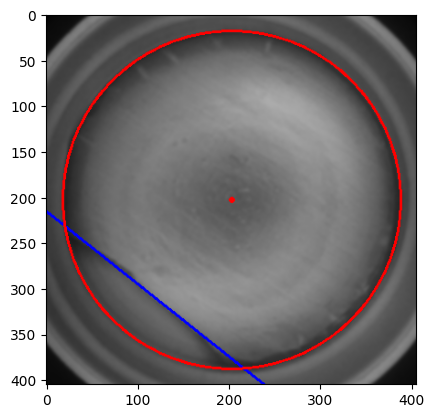

In [116]:
circle_liner_layer=np.zeros_like(img_color) ################################################################################################### PER RIQUADRO

if circles_in is not None and len(circles_in) > 0: ## usare la flag liner mettendo se si 

    center_in = (circles_in[0][0][0],circles_in[0][0][1])
    radius_in = circles_in[0][0][2]
    cv2.circle(img_color,(int(center_in[0]+x_min_roi),int(center_in[1]+y_min_roi)),int(radius_in),color=(255, 0, 0),thickness=2)
    cv2.circle(img_color,(int(center_in[0]+x_min_roi),int(center_in[1]+y_min_roi)),int(2),color=(255, 0, 0),thickness=2)

    cv2.circle(circle_liner_layer,(int(center_in[0])+x_min_roi,int(center_in[1])+y_min_roi),int(radius_in),color=(255,0, 0),thickness=2)#################################  PER RIQUADRO

    if show_steps: 
        cv2.circle(img_roi_show,(int(center_in[0]),int(center_in[1])),int(radius_in),color=(255, 0, 0),thickness=2)
        cv2.circle(img_roi_show,(int(center_in[0]),int(center_in[1])),int(2),color=(255,0, 0),thickness=2)
        print("LINER - center (in img_roi): x= ", center_in[0]," y= ",center_in[1]," , diameter= ",radius_in*2)
        plt.imshow(img_roi_show)
        plt.show()

    ########## maybe mostrare qua l'immagine del cerchio del liner nell'immagine grande (non roi) e printare le info di centro e diametro come per task 1
    


### print finale and optional requirement

print results and image with the rectangle around defect if present

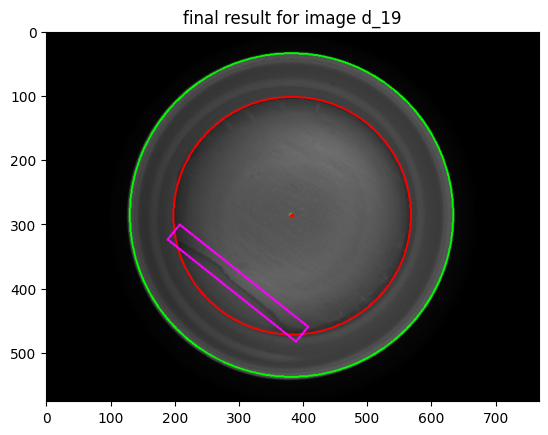

In [117]:
### print fatto bene info che vuole per task 1 (centro cap, diametro cap,liner missing, liner defective)
### e printa immagine con il rettangolo
##### print delle info  usando le flag 


##### maybe qui mettere solo la cosa aggiuntiva del rettangolo e magari un recap finale dopo aver già printato tutte le info importanti prima

########## if defect found

################################################## de- AI izzare questo pezzo di codice
liner_layer=line_layer+circle_liner_layer
mask = np.all(liner_layer == np.array([255, 0, 255], dtype=np.uint8), axis=2)
y, x = np.where(mask) 

#2 lists with some points of which to make sure i only get two that are in the two different intersections i take the first and last
x1=x[0]
y1=y[0]
x2=x[-1]
y2=y[-1]

dx = x2 - x1
dy = y2 - y1

# Calculate line length 
length = math.sqrt(dx**2+dy**2)

if length > 0:
    # Calculate perpendicular unit normal vector
    phix = -dy / length
    phiy = dx / length
    
    # Define how wide you want the rectangle to be on each side of the line
    width = 15
    
    # Calculate the four corners dynamically
    pt1 = [x1 + width *phix, y1 + width * phiy]
    pt2 = [x1 - width *phix, y1 - width * phiy]
    pt3 = [x2 - width *phix, y2 - width * phiy]
    pt4 = [x2 + width *phix, y2 + width * phiy]
    
    # Format the points into an array for OpenCV
    pts = np.array([pt1, pt2, pt3, pt4], dtype=np.int32)
    
    cv2.polylines(img_color, [pts], isClosed=True, color=(255, 0, 255), thickness=2)

plt.figure()
plt.title("final result for image "+img_name)
plt.imshow(img_color)
plt.show()